In [1]:
import numpy as np
import pandas as pd
import scanpy as sc
import sctk as sk
import matplotlib.pyplot as plt
import os
import sys
import scipy
import matplotlib
from matplotlib import rcParams
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "all" # to show output from all the lines in a cells
pd.set_option('display.max_column',None) # display all the columns in pandas
pd.options.display.max_rows = 100
rcParams['pdf.fonttype'] = 42
sc.settings.figdir = './figures/SGN_analysis/'
sc.settings.set_figure_params(dpi = 150, color_map = 'RdPu', dpi_save = 600, vector_friendly = True, format = 'pdf')

In [2]:
cd F:\PROJECTS\PROJECT_HUMAN_FETAL_COCHLEAE\WORKPLACE\R\sc_pipeline\

F:\PROJECTS\PROJECT_HUMAN_FETAL_COCHLEAE\WORKPLACE\R\sc_pipeline


In [3]:
data_dir = '/PROJECTS/PROJECT_HUMAN_FETAL_COCHLEAE/WORKPLACE/R/sc_pipeline/'
meta = pd.read_csv(data_dir+'metadata_v2.csv',index_col=0)
meta

,sample_id,sample_id2,donor,gw,gender,10xKit,sequencing,dataset
sample,,,,,,,,
9.5gw,gw9,gw9,not_provided_1,9,female,SC3,snRNA-seq,public
11.2gw,gw11,gw11,not_provided_2,11,male,SC3,snRNA-seq,public
14+3gw,gw14,gw14,F20240701,14,male,SC3,snRNA-seq,in-house
15gw,gw15,gw15,not_provided_3,15,female,SC3,scRNA-seq,public
16+4gw,gw16,gw16,F20241018,16,male,SC3,snRNA-seq,in-house
17+2gw,gw17_1,gw17_1,F20220807,17,male,SC3,snRNA-seq,in-house
17+3gw,gw17_2,gw17_2,F20240928,17,female,SC3,snRNA-seq,in-house
17gw,gw17_3,gw17_3,not_provided_4,17,male,SC3,scRNA-seq,public
18+3gw,gw18,gw18,F20220806,18,male,SC3,snRNA-seq,in-house


In [5]:
adata_mouse=sc.read("mouse_developmental_sgn_python_human_id.h5ad")
adata_mouse

AnnData object with n_obs × n_vars = 2444 × 16113
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'percent.mt', 'pRP', 'nCount_SCT', 'nFeature_SCT', 'SCT_snn_res.0.4', 'seurat_clusters', 'celltype', 'SCT_snn_res.1.2', 'SCT_snn_res.3', 'SCT_snn_res.0.8', 'SCT_snn_res.2'
    var: 'vst.mean', 'vst.variance', 'vst.variance.expected', 'vst.variance.standardized', 'vst.variable'
    obsm: 'X_harmony', 'X_pca', 'X_umap_harmony'

In [7]:
adata_mouse.obs['orig.ident'].value_counts()

orig.ident
Mouse_E16    701
Mouse_E18    697
Mouse_P3     511
Mouse_P25    186
Mouse_E15    150
Mouse_E14    126
Mouse_E17     73
Name: count, dtype: int64

In [8]:
adata_mouse.obs['celltype'].value_counts()

celltype
Immature_IB/C       874
Immature_IA/II      625
IA/2_precursor      237
IB/C_precursor      152
Immature_IA         139
Intermediate_SGN    108
Early_SGN            71
IB                   67
IA                   64
Immature_Type2       52
IC                   48
II                    7
Name: count, dtype: int64

In [9]:
adata_mouse.obsm['X_umap']=adata_mouse.obsm['X_umap_harmony']

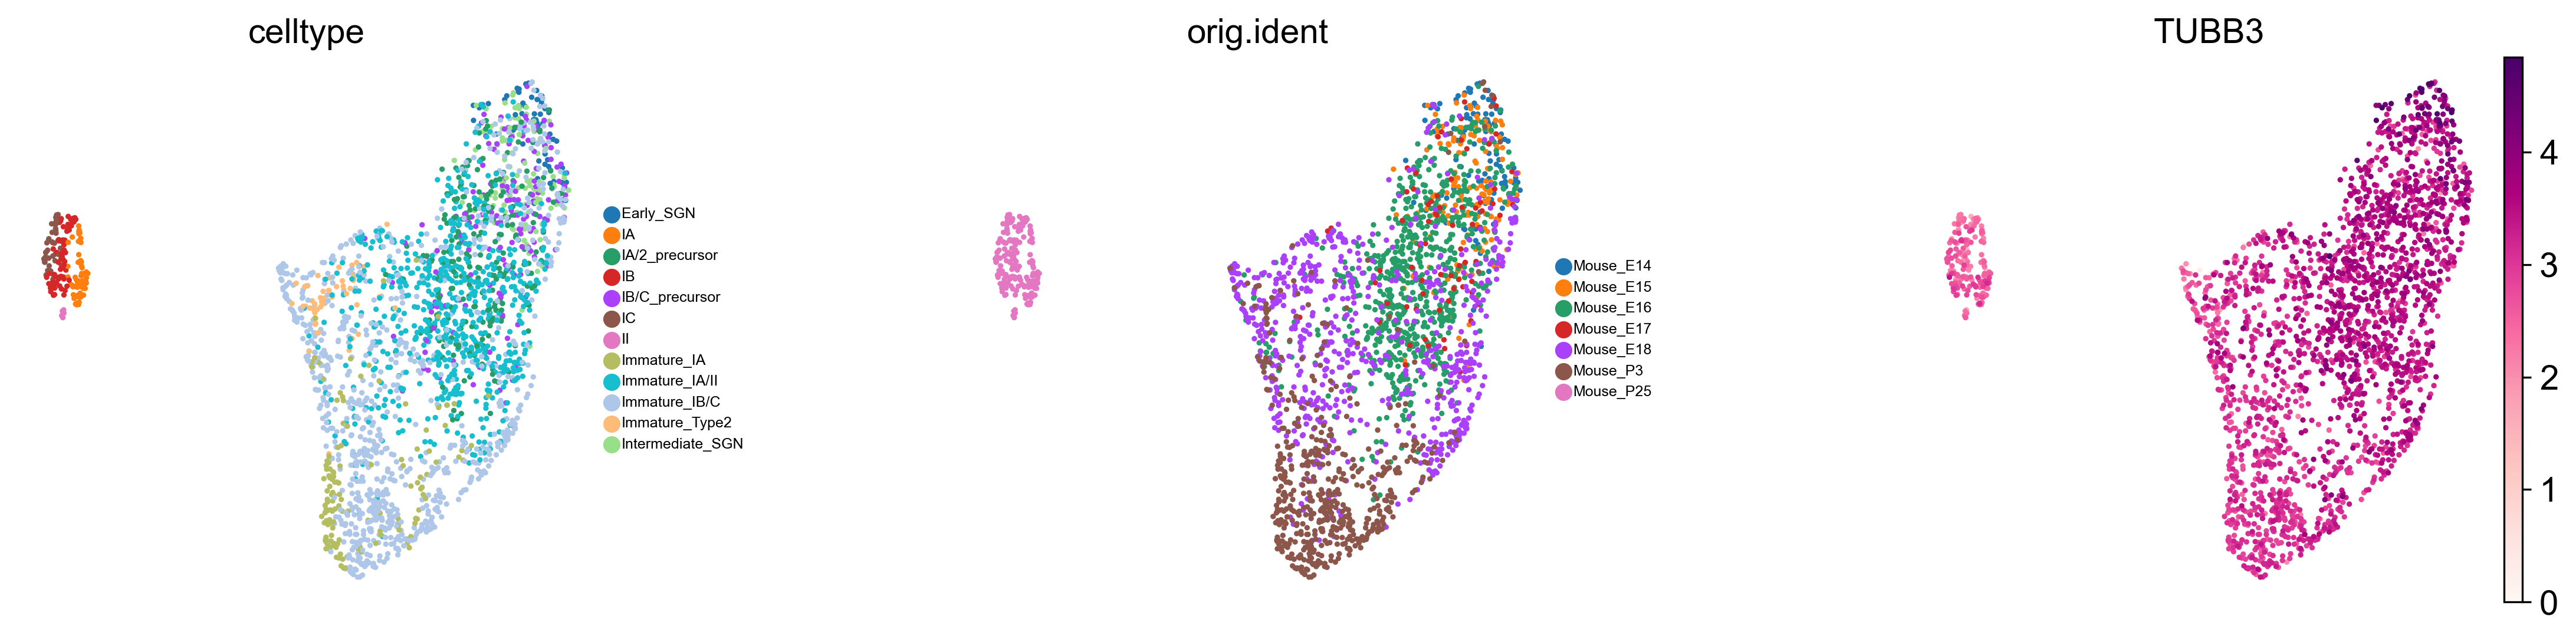

In [10]:
sc.set_figure_params(figsize=(4,4),frameon=False,dpi=150,dpi_save=600)
sc.pl.umap(adata_mouse, color=['celltype', 'orig.ident','TUBB3'
                                
                            ],
           size=20,
           legend_fontsize=6,ncols = 3,wspace = 0.5, )

In [13]:
adata_mouse.layers['counts']=adata_mouse.X.copy()

In [14]:
sc.pp.normalize_total(adata_mouse, target_sum=1e4)
sc.pp.log1p(adata_mouse)

In [15]:
adata_mouse.layers["logcounts"] = adata_mouse.X.copy()

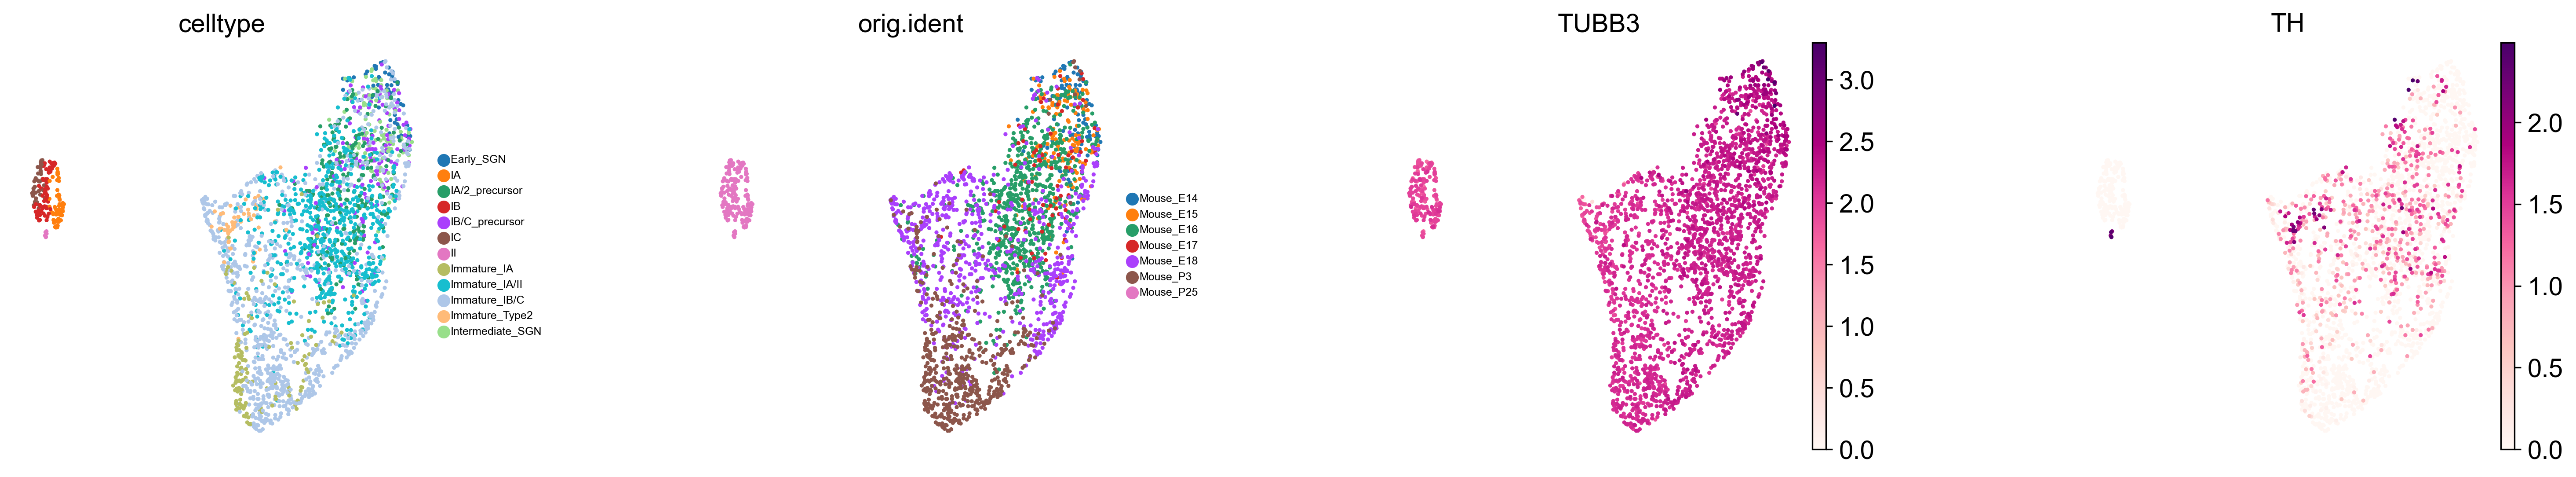

In [23]:
sc.set_figure_params(figsize=(4,4),frameon=False,dpi=150,dpi_save=600)
sc.pl.umap(adata_mouse, color=['celltype', 'orig.ident','TUBB3','TH'
                                
                            ],
           size=20,
           legend_fontsize=6,ncols = 4,wspace = 0.5, )

<Axes: ylabel='CALB2'>

<Axes: ylabel='LYPD1'>

<Axes: ylabel='TUBB3'>

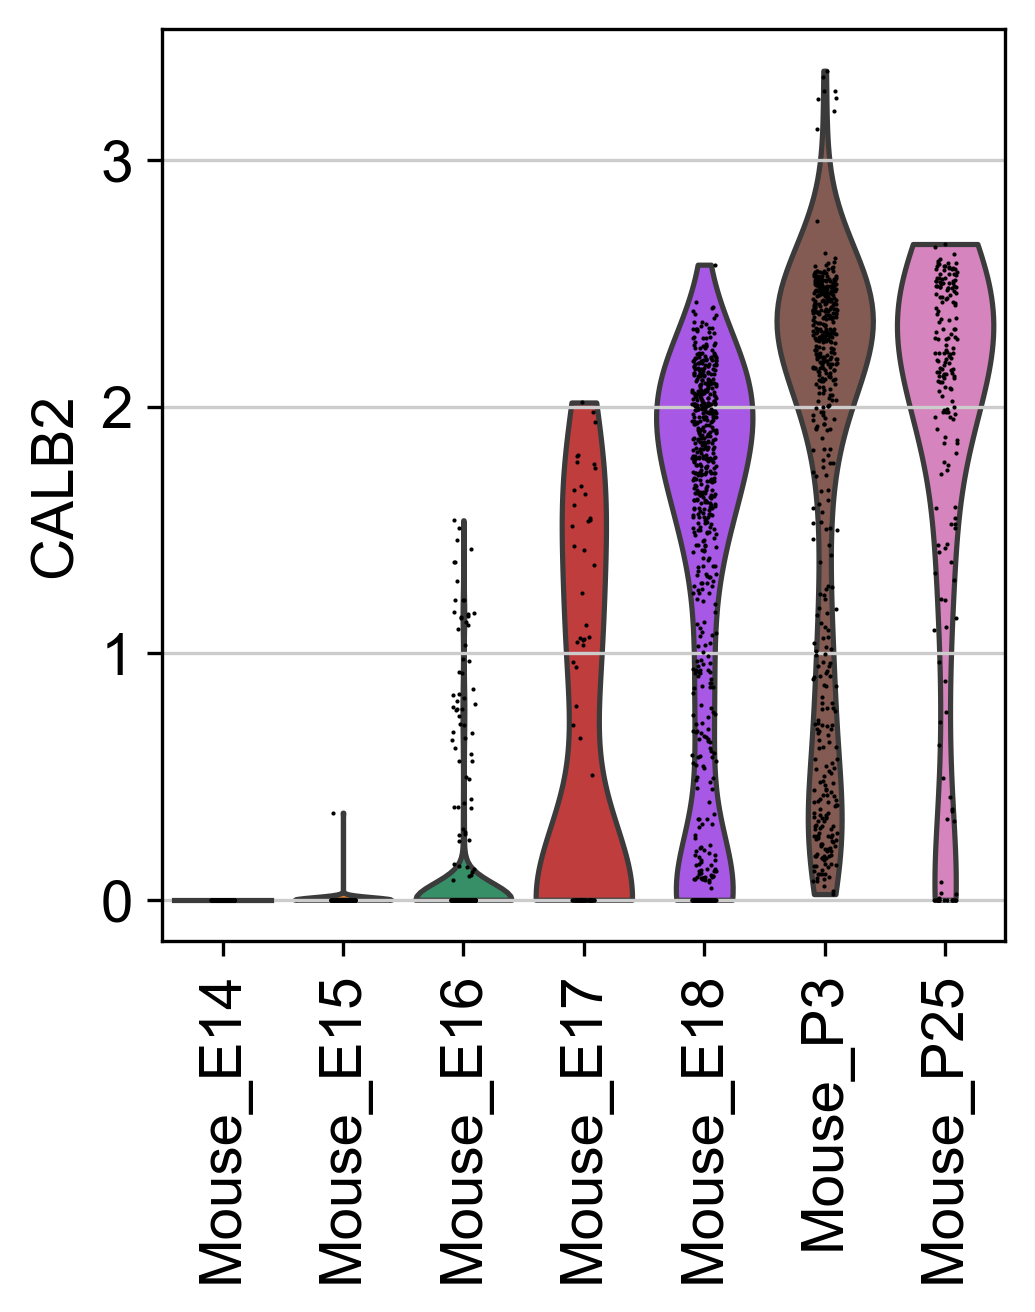

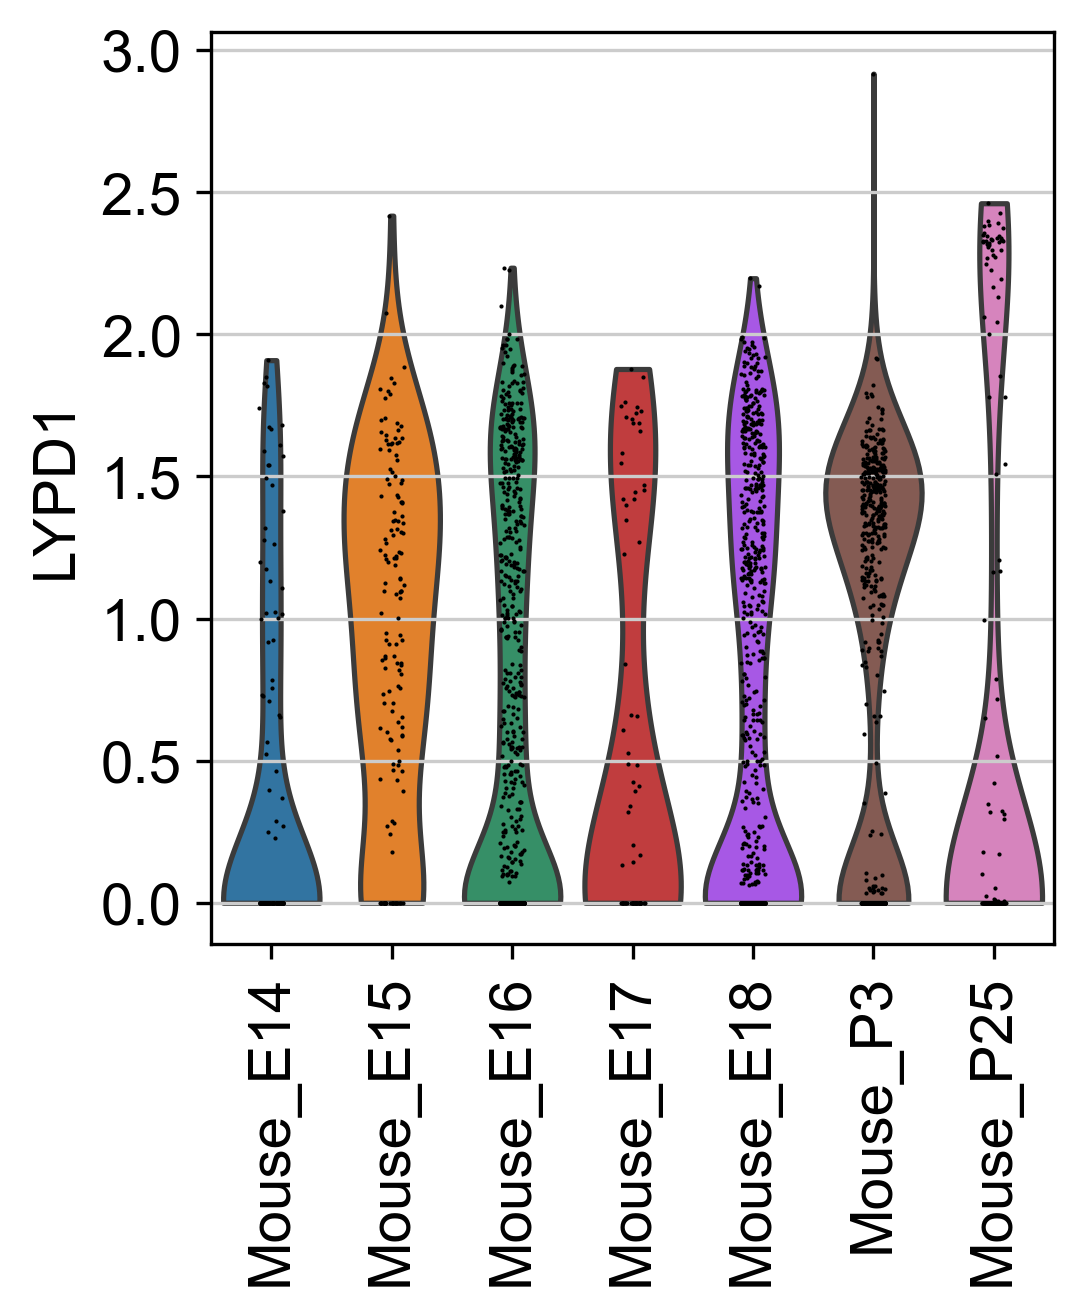

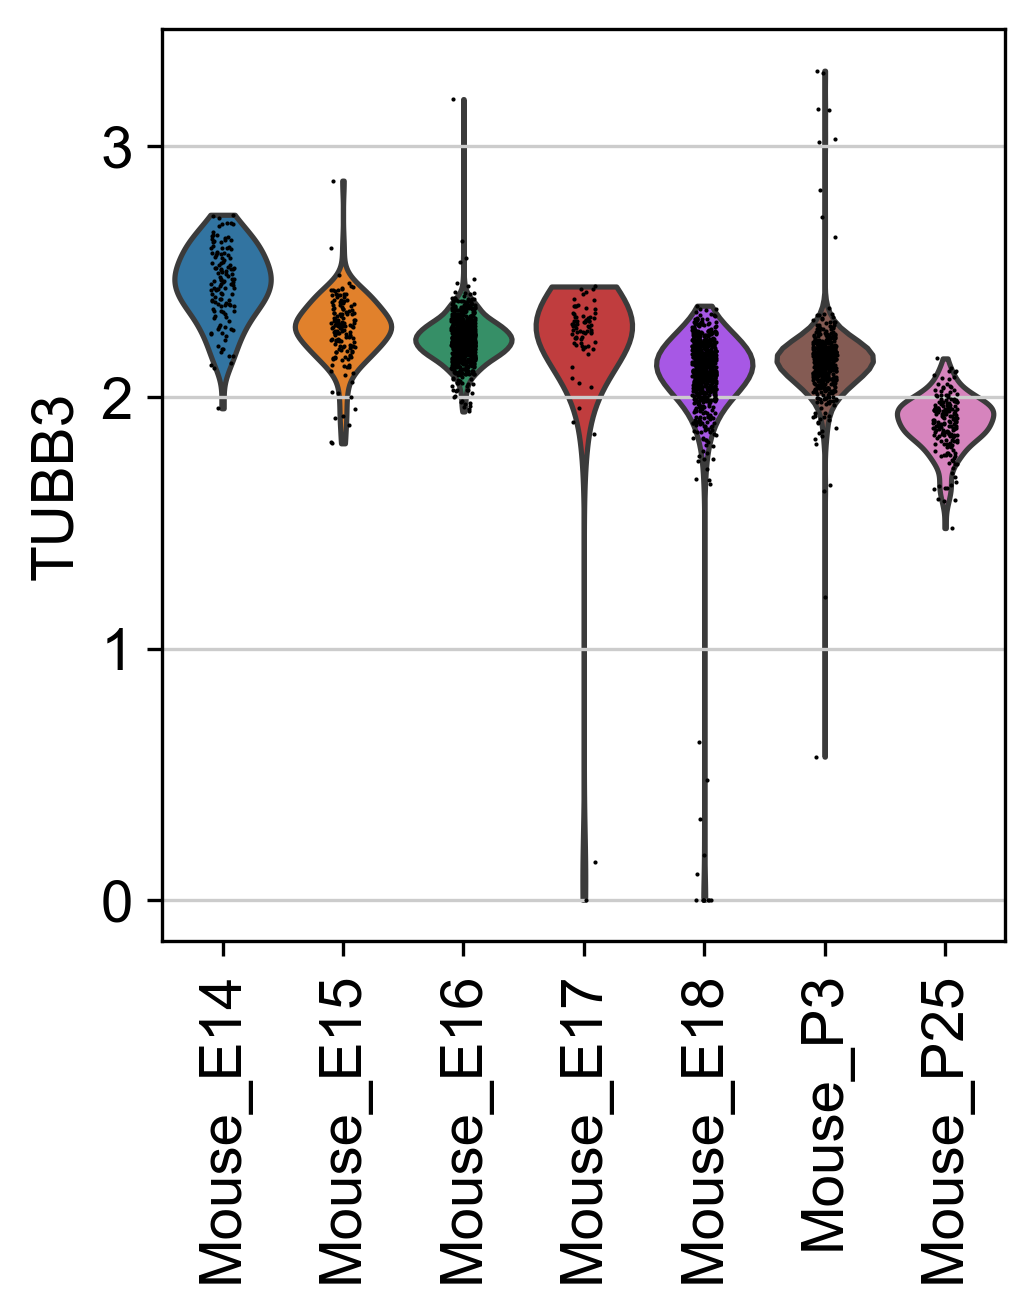

In [29]:
sc.pl.violin(adata_mouse, "CALB2", groupby='orig.ident', rotation=90, show=False)
sc.pl.violin(adata_mouse, "LYPD1", groupby='orig.ident', rotation=90, show=False)
sc.pl.violin(adata_mouse, "TUBB3", groupby='orig.ident', rotation=90, show=False)